# 01 - EDA And Validation Design

This notebook goes one level deeper.

Goals:
- inspect the dataset by year and sector
- think about what a realistic validation split should be
- build trivial baselines that future models must beat

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from IPython.display import display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

ROOT = Path.cwd().resolve().parent
DATA_DIR = ROOT / 'data' / 'raw'

sys.path.insert(0, str(ROOT / 'scripts'))
from data_prep import load_raw, time_split, rolling_time_splits, rmse  # noqa: E402

train, test, _ = load_raw(DATA_DIR)

# Use start_year as the observation-year feature (present in both train and test).
train['obs_year'] = train['start_year']
train['obs_quarter'] = train['period_start'].dt.quarter  # train-only diagnostic

train.shape

(23070, 41)

In [2]:
year_counts = train.groupby('obs_year')['id'].count().rename('rows')
ticker_counts = train.groupby('obs_year')['ticker'].nunique().rename('unique_tickers')
summary_by_year = pd.concat([year_counts, ticker_counts], axis=1)
display(summary_by_year)

if 'sector_code' in train.columns:
    sector_year = pd.crosstab(train['obs_year'], train['sector_code'])
    display(sector_year)


,rows,unique_tickers
obs_year,,
2019,5029,1318
2020,5339,1423
2021,6068,1613
2022,6634,1724


sector_code,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
obs_year,,,,,,,,,,,
2019,757,858,794,657,606,362,255,255,215,164,87
2020,835,888,816,717,660,385,275,258,225,168,90
2021,998,995,922,861,750,415,303,279,238,180,98
2022,1105,1099,1010,945,821,439,333,294,241,207,106


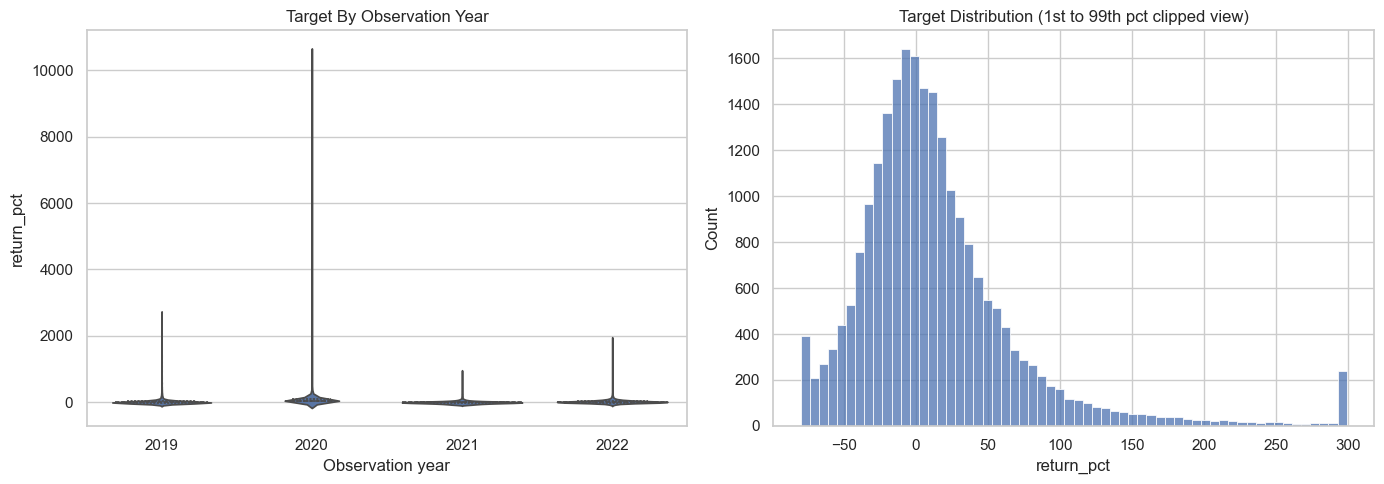

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=train, x='obs_year', y='return_pct', inner='quartile', ax=axes[0])
axes[0].set_title('Target By Observation Year')
axes[0].set_xlabel('Observation year')
axes[0].set_ylabel('return_pct')

clip_low = train['return_pct'].quantile(0.01)
clip_high = train['return_pct'].quantile(0.99)
clipped = train['return_pct'].clip(clip_low, clip_high)
sns.histplot(clipped, bins=60, ax=axes[1])
axes[1].set_title('Target Distribution (1st to 99th pct clipped view)')
axes[1].set_xlabel('return_pct')

plt.tight_layout()
plt.show()

In [4]:
missing_by_year = (
    train.groupby('obs_year')
    .apply(lambda frame: frame.isna().mean())
    .T
)

top_variable_features = (
    missing_by_year.max(axis=1) - missing_by_year.min(axis=1)
).sort_values(ascending=False)

display(top_variable_features.head(15).rename('missingness_range'))

selected_features = top_variable_features.head(10).index.tolist()
display(missing_by_year.loc[selected_features])

income_before_tax    0.243712
revenue_growth_3y    0.044950
rote                 0.044413
growth_pe_ratio      0.041676
long_term_debt       0.041575
roe                  0.041515
pe_ttm               0.039589
operating_margin     0.039179
debt_to_equity       0.038214
inventory            0.036867
net_margin           0.036263
price_to_sales       0.036001
revenue_ttm          0.035492
roa                  0.034108
net_income_ttm       0.034027
Name: missingness_range, dtype: float64

obs_year,2019,2020,2021,2022
income_before_tax,0.451581,0.437910,0.329103,0.207869
revenue_growth_3y,0.278385,0.297809,0.323336,0.316250
rote,0.171804,0.177561,0.216216,0.201236
growth_pe_ratio,0.322529,0.341262,0.364206,0.356045
long_term_debt,0.310400,0.318224,0.336355,0.351975
roe,0.195466,0.201536,0.236981,0.219626
pe_ttm,0.083516,0.087282,0.123105,0.111999
operating_margin,0.174389,0.178311,0.159361,0.139132
debt_to_equity,0.352953,0.360367,0.378708,0.391167
inventory,0.480016,0.487170,0.505933,0.516883


## Baseline Validation Choice

The defensible default split:

- **train** on rows with `start_year < 2022`
- **validate** on rows with `start_year == 2022`

Why 2022 specifically: the 2022 rows' forward-return windows realise in
**2023**, which is the only stretch of time no earlier training row's
label window covers. That mirrors the test situation, where the 2024
test rows' forward-return window (2024 → 2025) lies entirely outside
the training label coverage. Any earlier holdout (e.g. 2021) leaks
regime information from train rows whose forward windows overlap it.

We also fit an expanding-window diagnostic (20, 21, 22) below — not as
the primary scorecard, but to see how unstable the year-over-year
generalisation is. A model whose RMSE drifts a lot across folds will
also drift on test.

In [5]:
split = time_split(train, valid_year=2022)
print(split.description)

train_fold = train.iloc[split.train_idx].copy()
valid_fold = train.iloc[split.valid_idx].copy()

print('train fold:', train_fold.shape)
print('valid fold:', valid_fold.shape)
print('train period_start range:', train_fold['period_start'].min(), 'to', train_fold['period_start'].max())
print('valid period_start range:', valid_fold['period_start'].min(), 'to', valid_fold['period_start'].max())
print('valid period_end range:  ', valid_fold['period_end'].min(),   'to', valid_fold['period_end'].max())

train start_year<2022 -> validate start_year==2022; validation forward window ends 2023-12-31
train fold: (16436, 41)
valid fold: (6634, 41)
train period_start range: 2019-01-01 00:00:00 to 2021-12-31 00:00:00
valid period_start range: 2022-01-01 00:00:00 to 2022-12-31 00:00:00
valid period_end range:   2022-12-31 00:00:00 to 2023-12-31 00:00:00


In [6]:
# Trivial baselines on the 2022 holdout, using the project-wide rmse helper.
global_median = train_fold['return_pct'].median()
median_pred = np.full(len(valid_fold), global_median)
print('Global median baseline RMSE:', round(rmse(valid_fold['return_pct'], median_pred), 4))

if 'sector_code' in train.columns:
    sector_medians = train_fold.groupby('sector_code')['return_pct'].median()
    sector_pred = valid_fold['sector_code'].map(sector_medians).fillna(global_median)
    print('Sector median baseline RMSE:', round(rmse(valid_fold['return_pct'], sector_pred), 4))

Global median baseline RMSE: 65.3509
Sector median baseline RMSE: 65.2195


In [7]:
# Expanding-window diagnostic. Each fold trains on all earlier years.
fold_rows = []
for fold in rolling_time_splits(train, [2020, 2021, 2022]):
    train_y = train['return_pct'].iloc[fold.train_idx]
    valid_y = train['return_pct'].iloc[fold.valid_idx]
    median_pred = np.full(len(valid_y), train_y.median())
    fold_rows.append({
        'valid_year': fold.valid_year,
        'train_rows': len(fold.train_idx),
        'valid_rows': len(fold.valid_idx),
        'unique_train_tickers': train.iloc[fold.train_idx]['ticker'].nunique(),
        'unique_valid_tickers': train.iloc[fold.valid_idx]['ticker'].nunique(),
        'median_baseline_rmse': round(rmse(valid_y, median_pred), 3),
    })

display(pd.DataFrame(fold_rows))

,valid_year,train_rows,valid_rows,unique_train_tickers,unique_valid_tickers,median_baseline_rmse
0,2020,5029,5339,1318,1423,266.897
1,2021,10368,6068,1432,1613,49.941
2,2022,16436,6634,1622,1724,65.351


## Recommended Takeaways

- Use a time-aware split as the default standard.
- Benchmark every model against trivial baselines.
- Track whether performance is stable across years, not just on one holdout.
- Treat sector effects and missingness as potential signal sources.

Next: open `02_baseline_models_and_submission.ipynb` to build a first real submission.